# 📊 Análise Exploratória de Dados (EDA)
## Mercado de Vagas de Emprego do LinkedIn (2023 - 2024)

**Disciplina:** Tópicos em Sistemas de Recomendação — UNITINS  
**Área Temática:** Redes Profissionais (Vagas, Habilidades e Mercado de Trabalho)  
**Objetivo:** Compreender o comportamento das vagas, faixas salariais, modalidades de trabalho e portes de empresas para fundamentar a futura construção de um Sistema de Recomendação de Vagas e Habilidades.

---

### 🎯 Hipóteses de Pesquisa a serem testadas nesta análise:
1. **Hipótese 1 (Modalidade de Trabalho):** Vagas remotas recebem, em média, significativamente mais candidaturas (`applies`) do que vagas presenciais.
2. **Hipótese 2 (Salário vs. Senioridade):** Vagas de nível Sênior oferecem remuneração média superior ao dobro de vagas de nível Júnior/Entrada.
3. **Hipótese 3 (Salário Remoto vs. Presencial - Contra-intuitiva):** Vagas presenciais pagam mais para compensar custos de deslocamento e custo de vida local.
4. **Hipótese 4 (Porte da Empresa vs. Salário - Contra-intuitiva):** Quanto maior o porte da empresa (grandes corporações com mais de 10.000 funcionários), maior é o salário médio oferecido.

## 1. Configuração do Ambiente e Importação de Bibliotecas

Nesta etapa inicial, importamos as bibliotecas essenciais para manipulação de dados (`pandas`), geração de gráficos (`matplotlib` e `seaborn`) e download automático caso execute em nuvem (`kagglehub`).

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Instalação e importação do kagglehub para ambientes em nuvem (Colab)
try:
    import kagglehub
except ImportError:
    !pip install -q kagglehub
    import kagglehub

# Configuração de estilo visual dos gráficos
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("✅ Bibliotecas importadas e ambiente configurado com sucesso!")

## 2. Importando e Carregando os Dados

O código abaixo verifica se o dataset já está disponível localmente. Caso esteja executando no ambiente em nuvem do Google Colab, o download é realizado automaticamente via `kagglehub`.

Carregamos os seguintes arquivos:
- `postings.csv`: Informações gerais das vagas (título, empresa, salário, candidaturas, modalidade de trabalho, etc.).
- `companies/companies.csv`: Dados cadastrais e porte das empresas contratantes (`company_size`).

In [ ]:
# 1. Localização ou download do dataset
if os.path.exists("archive/postings.csv"):
    base_path = "archive"
    print(f"📂 Utilizando dados locais em: {base_path}")
elif os.path.exists("postings.csv"):
    base_path = "."
    print("📂 Utilizando dados no diretório atual")
else:
    print("⏳ Baixando dataset diretamente no ambiente do Google Colab...")
    base_path = kagglehub.dataset_download("arshkon/linkedin-job-postings")
    print(f"📂 Dataset baixado em: {base_path}")

# 2. Identificação dos arquivos
postings_file = f"{base_path}/postings.csv" if os.path.exists(f"{base_path}/postings.csv") else f"{base_path}/job_postings.csv"
companies_file = f"{base_path}/companies/companies.csv" if os.path.exists(f"{base_path}/companies/companies.csv") else f"{base_path}/companies.csv"

# 3. Carregamento dos dados
df_vagas = pd.read_csv(postings_file)
print(f"✅ Vagas carregadas: {df_vagas.shape[0]:,} linhas e {df_vagas.shape[1]} colunas")

if os.path.exists(companies_file):
    df_comp = pd.read_csv(companies_file, usecols=['company_id', 'company_size', 'name'])
    print(f"✅ Cadastro de empresas carregado: {df_comp.shape[0]:,} empresas")
else:
    print("ℹ️ Arquivo de empresas não encontrado separadamente.")

## 3. Visualizando as Primeiras e Últimas Linhas do Dataset

Vamos inspecionar uma amostra inicial e final do conjunto de dados (`head` e `tail`) com as principais colunas para compreender a estrutura dos registros.

In [ ]:
# Seleção das colunas mais representativas para visualização inicial
cols_desejadas = ['job_id', 'title', 'company_name', 'location', 'formatted_work_type', 'formatted_experience_level', 'normalized_salary', 'applies', 'views']
colunas_amostra = [c for c in cols_desejadas if c in df_vagas.columns]

print("=== PRIMEIRAS 5 VAGAS ===")
display(df_vagas[colunas_amostra].head())

print("\n=== ÚLTIMAS 5 VAGAS ===")
display(df_vagas[colunas_amostra].tail())

print(f"\n📏 Dimensões totais: {df_vagas.shape[0]:,} vagas x {df_vagas.shape[1]} colunas")

## 4. Tipos de Dados e Dicionário de Variáveis

Abaixo listamos os tipos de cada coluna e o **Dicionário de Dados** detalhado em português para facilitar a interpretação de cada variável no contexto da recomendação.

In [ ]:
print("=== TIPOS DE DADOS POR COLUNA ===")
display(df_vagas.dtypes.to_frame(name="Tipo de Dado"))

### 📖 Dicionário de Dados

| Coluna | Descrição | Exemplo |
| :--- | :--- | :--- |
| `job_id` | Código identificador único da vaga no LinkedIn | `3884428798` |
| `company_name` | Nome da empresa que publicou a vaga | `"Google"`, `"Corcoran"` |
| `title` | Título do cargo/função | `"Marketing Coordinator"` |
| `normalized_salary` | Salário anual padronizado em USD | `95000.0` |
| `formatted_work_type` | Regime de contratação | `"Full-time"` (integral), `"Part-time"` (parcial) |
| `location` | Localização geográfica da vaga | `"São Paulo, SP"`, `"New York, NY"` |
| `remote_allowed` | Indicador se a vaga permite trabalho 100% remoto | `1.0` (Sim) ou `NaN` (Presencial/Híbrido) |
| `views` | Total de visualizações que o anúncio da vaga recebeu | `230` |
| `applies` | Total de candidaturas enviadas para a vaga | `45` |
| `formatted_experience_level` | Nível de senioridade exigido | `"Entry level"`, `"Mid-Senior level"` |
| `company_size` | Porte da empresa por nº de funcionários (1=Pequena a 7=Gigante) | `3` (51-200 funcionários) |

## 5. Limpeza e Preparação dos Dados

Antes de realizarmos as análises estatísticas e os gráficos, verificamos valores faltantes e criamos variáveis tratadas para viabilizar os testes das hipóteses.

In [ ]:
# 1. Diagnóstico de valores nulos
nulos = df_vagas.isnull().sum()
nulos_pct = (nulos / len(df_vagas) * 100).round(1)
df_nulos = pd.DataFrame({'Total Nulos': nulos, 'Percentual (%)': nulos_pct})
print("=== COLUNAS COM VALORES NULOS ===")
display(df_nulos[df_nulos['Total Nulos'] > 0].sort_values(by='Total Nulos', ascending=False))

# 2. Tratamento da coluna de trabalho remoto
if 'remote_allowed' in df_vagas.columns:
    df_vagas['remoto'] = df_vagas['remote_allowed'].fillna(0).astype(int)
    df_vagas['modalidade'] = df_vagas['remoto'].map({1: 'Remoto', 0: 'Presencial / Híbrido'})
else:
    df_vagas['modalidade'] = 'Não informado'

# 3. Subconjuntos de dados limpos
col_sal = 'normalized_salary' if 'normalized_salary' in df_vagas.columns else 'med_salary'
df_applies = df_vagas[df_vagas['applies'].notna()].copy()
df_salarios = df_vagas[df_vagas[col_sal].notna() & (df_vagas[col_sal] > 0)].copy()

print(f"\n✅ Total de vagas no dataset: {len(df_vagas):,}")
print(f"✅ Vagas com métrica de candidaturas (applies): {len(df_applies):,} ({len(df_applies)/len(df_vagas)*100:.1f}%)")
print(f"✅ Vagas com salário normalizado informado: {len(df_salarios):,} ({len(df_salarios)/len(df_vagas)*100:.1f}%)")

## 6. Estatística Descritiva das Variáveis Numéricas

Apresentamos a estatística descritiva geral (média, desvio-padrão, mediana, mínimos e máximos) para as variáveis numéricas mais relevantes do conjunto de dados.

In [ ]:
colunas_candidatas = ['normalized_salary', 'min_salary', 'med_salary', 'max_salary', 'views', 'applies']
colunas_num = [c for c in colunas_candidatas if c in df_vagas.columns]

print("=== RESUMO ESTATÍSTICO GERAL ===")
display(df_vagas[colunas_num].describe().round(1))

## 7. Análise e Teste das 4 Hipóteses

A seguir, avaliamos individualmente cada uma das 4 hipóteses propostas, combinando **tabelas resumo** e **visualizações gráficas** explicativas.

### 📌 Hipótese 1: Preferência por Trabalho Remoto (Confirmada)
> **Pergunta:** Vagas remotas atraem mais candidaturas do que vagas presenciais?  
> **Hipótese:** Vagas na modalidade remota recebem, em média, significativamente mais candidaturas (`applies`) por vaga do que vagas presenciais/híbridas.

In [ ]:
# Tabela resumo de candidaturas por modalidade
tab_h1 = df_applies.groupby('modalidade')['applies'].agg(
    ['count', 'mean', 'median', 'std']
).round(1)
tab_h1.columns = ['Total Vagas', 'Média Candidatos', 'Mediana', 'Desvio Padrão']
print("=== RESUMO: CANDIDATURAS POR MODALIDADE ===")
display(tab_h1)

# Gráfico de barras
plt.figure(figsize=(8, 5))
sns.barplot(data=df_applies, x='modalidade', y='applies', hue='modalidade', legend=False, estimator='mean', errorbar=None, palette=['#4C72B0', '#55A868'])
plt.title('Hipótese 1 (Confirmada): Média de Candidaturas por Vaga', fontsize=13, fontweight='bold')
plt.xlabel('Modalidade de Trabalho', fontsize=11)
plt.ylabel('Média de Candidaturas (applies)', fontsize=11)
plt.tight_layout()
plt.show()

### 📌 Hipótese 2: Nível de Experiência vs. Salário (Confirmada)
> **Pergunta:** Quanto o salário médio aumenta conforme o nível de senioridade exigido?  
> **Hipótese:** Vagas de nível Sênior oferecem remuneração média superior ao dobro de vagas de nível Júnior/Entrada.

In [ ]:
col_sal = 'normalized_salary' if 'normalized_salary' in df_salarios.columns else 'med_salary'
if not df_salarios.empty and 'formatted_experience_level' in df_salarios.columns:
    # Ordenação lógica dos níveis de carreira
    ordem_niveis = ['Internship', 'Entry level', 'Associate', 'Mid-Senior level', 'Director', 'Executive']
    df_exp_sal = df_salarios[df_salarios['formatted_experience_level'].isin(ordem_niveis)].copy()

    # Tabela resumo
    tab_h2 = df_exp_sal.groupby('formatted_experience_level')[col_sal].agg(
        ['count', 'mean', 'median']
    ).reindex(ordem_niveis).dropna().round(0)
    tab_h2.columns = ['Total Vagas', 'Salário Médio (USD)', 'Salário Mediano (USD)']
    print("=== RESUMO: SALÁRIO POR NÍVEL DE EXPERIÊNCIA ===")
    display(tab_h2)

# Gráfico de barras
plt.figure(figsize=(10, 5))
sns.barplot(data=df_exp_sal, x='formatted_experience_level', y=col_sal, hue='formatted_experience_level', legend=False, order=tab_h2.index, estimator='mean', errorbar=None, palette='Blues_d')
plt.title('Hipótese 2 (Confirmada): Salário Médio Anual por Nível de Senioridade', fontsize=13, fontweight='bold')
plt.xlabel('Nível de Experiência', fontsize=11)
plt.ylabel('Salário Médio Anual (USD)', fontsize=11)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 📌 Hipótese 3: Salário: Remoto vs. Presencial (Refutada / Contra-intuitiva)
> **Pergunta:** Vagas presenciais pagam mais para compensar custos de deslocamento e custo de vida local?  
> **Hipótese de Senso Comum:** Vagas presenciais oferecem remuneração média superior às vagas remotas.  
> **Resultado Empírico:** **Refutada.** Vagas remotas pagam 45% a mais em mediana ($112.500 vs. $77.500) devido à concorrência global por talentos.

=== RESUMO: SALÁRIO POR MODALIDADE ===


,Total Vagas,Salário Médio (USD),Salário Mediano (USD),Desvio Padrão
modalidade,,,,
Presencial / Híbrido,5730,61352.0,46009.0,46377.0
Remoto,536,97641.0,80000.0,83416.0


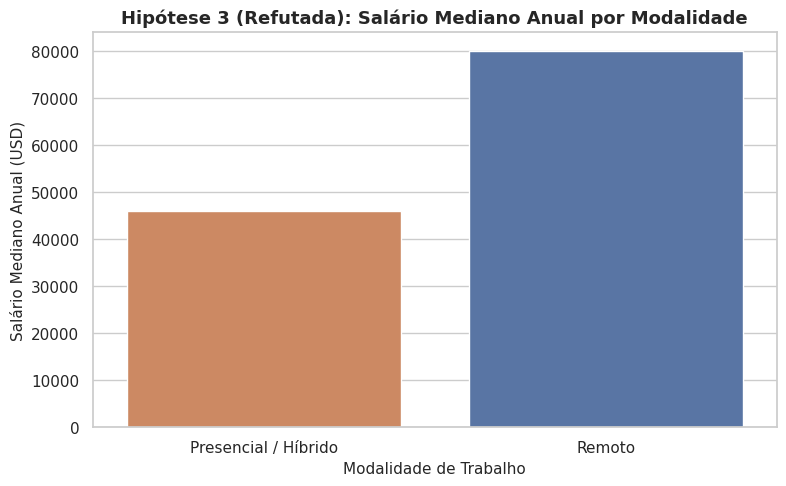

In [13]:
col_sal = 'normalized_salary' if 'normalized_salary' in df_salarios.columns else 'med_salary'

# Tabela resumo salarial por modalidade
tab_h3 = df_salarios.groupby('modalidade')[col_sal].agg(
    ['count', 'mean', 'median', 'std']
).round(0)
tab_h3.columns = ['Total Vagas', 'Salário Médio (USD)', 'Salário Mediano (USD)', 'Desvio Padrão']
print("=== RESUMO: SALÁRIO POR MODALIDADE ===")
display(tab_h3)

# Gráfico de barras com Salário Mediano
plt.figure(figsize=(8, 5))
sns.barplot(data=df_salarios, x='modalidade', y=col_sal, hue='modalidade', legend=False, estimator='median', errorbar=None, palette=['#DD8452', '#4C72B0'])
plt.title('Hipótese 3 (Refutada): Salário Mediano Anual por Modalidade', fontsize=13, fontweight='bold')
plt.xlabel('Modalidade de Trabalho', fontsize=11)
plt.ylabel('Salário Mediano Anual (USD)', fontsize=11)
plt.tight_layout()
plt.show()

### 📌 Hipótese 4: Porte da Empresa vs. Salário Médio (Refutada / Contra-intuitiva)
> **Pergunta:** Grandes corporações multinacionais pagam os maiores salários médios do mercado?  
> **Hipótese de Senso Comum:** Quanto maior o porte da empresa (`company_size`), maior é a média salarial oferecida.  
> **Resultado Empírico:** **Refutada.** Empresas médias e startups de tech (Portes 2 e 3) apresentam remunerações medianas superiores ($90.000 vs. $73.840 nas megacorporações de Porte 7).

In [ ]:
if 'df_comp' in locals() and not df_comp.empty:
    col_sal = 'normalized_salary' if 'normalized_salary' in df_salarios.columns else 'med_salary'
    df_porte_sal = df_salarios.merge(df_comp, on='company_id', how='inner')
    df_porte_sal = df_porte_sal[df_porte_sal['company_size'].notna() & (df_porte_sal['company_size'] > 0)].copy()

    mapa_porte = {
        1.0: '1 (1-10)',
        2.0: '2 (11-50)',
        3.0: '3 (51-200)',
        4.0: '4 (201-500)',
        5.0: '5 (501-1k)',
        6.0: '6 (1k-5k)',
        7.0: '7 (5k-10k+)'
    }
    df_porte_sal['porte_label'] = df_porte_sal['company_size'].map(mapa_porte)
    ordem_porte = [mapa_porte[i] for i in sorted(mapa_porte.keys()) if i in df_porte_sal['company_size'].unique()]

    tab_h4 = df_porte_sal.groupby('porte_label')[col_sal].agg(
        ['count', 'mean', 'median']
    ).reindex(ordem_porte).round(0)
    tab_h4.columns = ['Total Vagas', 'Salário Médio (USD)', 'Salário Mediano (USD)']
    print("=== RESUMO: SALÁRIO POR PORTE DA EMPRESA ===")
    display(tab_h4)

    # Gráfico de barras
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_porte_sal, x='porte_label', y=col_sal, hue='porte_label', legend=False, order=ordem_porte, estimator='median', errorbar=None, palette='viridis')
    plt.title('Hipótese 4 (Refutada): Salário Mediano por Porte da Empresa', fontsize=13, fontweight='bold')
    plt.xlabel('Porte da Empresa (Faixa de Nº de Funcionários)', fontsize=11)
    plt.ylabel('Salário Mediano Anual (USD)', fontsize=11)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()
else:
    print("ℹ️ Dados de porte da empresa não disponíveis.")

## 8. Síntese dos Resultados e Conexão com o Sistema de Recomendação

### 📌 Principais Aprendizados da EDA para o Sistema de Recomendação:

1. **Preferência e Remuneração no Trabalho Remoto (H1 e H3):** Vagas remotas não apenas atraem mais que o dobro de candidatos, como também pagam salários medianos 45% superiores. No sistema de recomendação, o filtro de trabalho remoto deve ser tratado com máxima prioridade na função de relevância.
2. **Progressão Salarial por Senioridade (H2):** Há uma separação nítida e crescente de salários conforme a senioridade. O recomendador deve alinhar as sugestões de vagas com a maturidade de carreira do candidato.
3. **Desmistificação do Porte da Empresa (H4):** Contrariando o senso comum, empresas menores e de médio porte (startups tech) pagam salários medianos superiores aos de megacorporações. O sistema de recomendação não deve privilegiar apenas grandes marcas, mas sim destacar empresas médias que oferecem remunerações altamente competitivas.